# LG전자 기업가치 제고 프로그램 & 투자자 포럼 워드클라우드 분석

## 📋 분석 개요
- **목적**: LG전자 기업가치 제고 프로그램 및 투자자 포럼 자료에서 핵심 키워드 추출 및 시각화
- **데이터**: 2024년 Corporate Value-up Program, LG Investor Forum 2024 PDF 파일
- **방법**: PDF 텍스트 추출 → 토큰화 → DataFrame → XML → 워드클라우드

## 📂 분석 대상 파일
1. `2024_LG_Electronics_Corporate_Value-up_Program.pdf`
2. `2024_LG_Electronics_Corporate_Value-up_Program-2.pdf`
3. `LG_Investor_Forum_2024.pdf`

In [21]:
# 필요한 라이브러리 설치 (최초 1회만 실행)
# !pip install PyPDF2 pdfplumber wordcloud konlpy matplotlib seaborn pandas numpy lxml beautifulsoup4

In [22]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import xml.etree.ElementTree as ET
from xml.dom import minidom
import warnings
import os
warnings.filterwarnings('ignore')

# PDF 처리
import PyPDF2
import pdfplumber

# 자연어 처리
try:
    from konlpy.tag import Okt, Mecab, Kkma
    KONLPY_AVAILABLE = True
except ImportError:
    KONLPY_AVAILABLE = False
    print("⚠️ KoNLPy가 설치되지 않았습니다. 간단한 토큰화를 사용합니다.")

from collections import Counter

# 워드클라우드
from wordcloud import WordCloud

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 로딩 완료!")
print(f"📍 현재 작업 디렉토리: {os.getcwd()}")

✅ 라이브러리 로딩 완료!
📍 현재 작업 디렉토리: c:\Users\lgdx\LG_DX_School\02_DX_Methodology\1_Business_Experience_BX


In [23]:
# PDF 파일 경로 설정
pdf_files = {
    'Corporate_Value_up_1': '2024_LG_Electronics_Corporate_Value-up_Program.pdf',
    'Corporate_Value_up_2': '2024_LG_Electronics_Corporate_Value-up_Program-2.pdf',
    'Investor_Forum': 'LG_Investor_Forum_2024.pdf'
}

# IR_Report 디렉토리 경로
ir_report_dir = Path('../IR_Report')
print(f"IR Report 디렉토리: {ir_report_dir.absolute()}")

# 파일 존재 여부 확인
existing_files = {}
for doc_type, filename in pdf_files.items():
    file_path = ir_report_dir / filename
    if file_path.exists():
        existing_files[doc_type] = file_path
        print(f"✅ {doc_type}: {filename}")
        print(f"   📏 파일 크기: {file_path.stat().st_size / 1024:.1f} KB")
    else:
        print(f"❌ {doc_type}: {filename} - 파일을 찾을 수 없습니다.")
        print(f"   📁 찾은 경로: {file_path.absolute()}")

print(f"\n📊 분석 가능한 파일 수: {len(existing_files)}개")

IR Report 디렉토리: c:\Users\lgdx\LG_DX_School\02_DX_Methodology\1_Business_Experience_BX\..\IR_Report
✅ Corporate_Value_up_1: 2024_LG_Electronics_Corporate_Value-up_Program.pdf
   📏 파일 크기: 1906.2 KB
✅ Corporate_Value_up_2: 2024_LG_Electronics_Corporate_Value-up_Program-2.pdf
   📏 파일 크기: 793.3 KB
✅ Investor_Forum: LG_Investor_Forum_2024.pdf
   📏 파일 크기: 28885.8 KB

📊 분석 가능한 파일 수: 3개


In [24]:
def extract_text_from_pdf(file_path):
    """
    PDF 파일에서 텍스트 추출
    pdfplumber와 PyPDF2를 모두 시도하여 최대한 많은 텍스트 추출
    """
    text = ""
    
    print(f"  📖 {file_path.name} 텍스트 추출 시작...")
    
    # Method 1: pdfplumber 시도
    try:
        with pdfplumber.open(file_path) as pdf:
            print(f"     📄 총 페이지 수: {len(pdf.pages)}")
            for i, page in enumerate(pdf.pages):
                if i % 10 == 0:  # 10페이지마다 진행상황 출력
                    print(f"     📃 페이지 {i+1} 처리 중...")
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
        print(f"     ✅ pdfplumber로 텍스트 추출 성공: {len(text):,}자")
    except Exception as e:
        print(f"     ❌ pdfplumber 실패: {e}")
    
    # Method 2: PyPDF2로 추가 시도 (텍스트가 적을 경우)
    if len(text) < 1000:
        try:
            print(f"     🔄 PyPDF2로 재시도...")
            with open(file_path, 'rb') as file:
                pdf_reader = PyPDF2.PdfReader(file)
                additional_text = ""
                for page in pdf_reader.pages:
                    page_text = page.extract_text()
                    if page_text:
                        additional_text += page_text + "\n"
                
                if len(additional_text) > len(text):
                    text = additional_text
                    print(f"     ✅ PyPDF2로 더 많은 텍스트 추출: {len(text):,}자")
        except Exception as e:
            print(f"     ❌ PyPDF2 실패: {e}")
    
    return text

# 모든 PDF 파일에서 텍스트 추출
extracted_texts = {}

print("🚀 PDF 텍스트 추출 시작...\n")

for doc_type, file_path in existing_files.items():
    print(f"📄 {doc_type} 파일 처리 중...")
    text = extract_text_from_pdf(file_path)
    
    if text.strip():
        extracted_texts[doc_type] = text
        print(f"  📊 추출된 텍스트 길이: {len(text):,}자")
        print(f"  📝 미리보기: {text[:150].replace(chr(10), ' ')}...")
    else:
        print(f"  ❌ 텍스트 추출 실패")
    print()

print(f"🎉 총 {len(extracted_texts)}개 파일에서 텍스트 추출 완료!")
total_chars = sum(len(text) for text in extracted_texts.values())
print(f"📊 전체 추출된 텍스트: {total_chars:,}자")

🚀 PDF 텍스트 추출 시작...

📄 Corporate_Value_up_1 파일 처리 중...
  📖 2024_LG_Electronics_Corporate_Value-up_Program.pdf 텍스트 추출 시작...


Cannot set gray non-stroke color because /'P957' is an invalid float value
Cannot set gray non-stroke color because /'P994' is an invalid float value
Cannot set gray non-stroke color because /'P1011' is an invalid float value


     📄 총 페이지 수: 11
     📃 페이지 1 처리 중...


Cannot set gray non-stroke color because /'P1023' is an invalid float value
Cannot set gray non-stroke color because /'P1039' is an invalid float value
Cannot set gray non-stroke color because /'P1047' is an invalid float value
Cannot set gray non-stroke color because /'P1069' is an invalid float value
Cannot set gray non-stroke color because /'P1086' is an invalid float value
Cannot set gray non-stroke color because /'P1222' is an invalid float value
Cannot set gray non-stroke color because /'P1313' is an invalid float value
Cannot set gray non-stroke color because /'P1336' is an invalid float value
Cannot set gray non-stroke color because /'P1363' is an invalid float value
Cannot set gray non-stroke color because /'P1400' is an invalid float value
Cannot set gray non-stroke color because /'P1426' is an invalid float value
Cannot set gray non-stroke color because /'P1451' is an invalid float value
Cannot set gray non-stroke color because /'P1500' is an invalid float value
Cannot set g

     📃 페이지 11 처리 중...
     ✅ pdfplumber로 텍스트 추출 성공: 137자
     🔄 PyPDF2로 재시도...
  📊 추출된 텍스트 길이: 137자
  📝 미리보기: 美 Deep Tech 등 글로벌 트렌드를 고려한 고객가치 측면의 신사업 Seeds 발굴 미래 사업 전략과 align된 기술 개발 자사만의 품질, 생산, 영업 등의 강점을 기반으로 신사업을주력 사업으로 육성 • • • • • • 年 • 年 • 年 ...

📄 Corporate_Value_up_2 파일 처리 중...
  📖 2024_LG_Electronics_Corporate_Value-up_Program-2.pdf 텍스트 추출 시작...


...

     📃 페이지 91 처리 중...


Cannot set gray non-stroke color because /'P6809' is an invalid float value
Cannot set gray non-stroke color because /'P6815' is an invalid float value
Cannot set gray non-stroke color because /'P6821' is an invalid float value
Cannot set gray non-stroke color because /'P6843' is an invalid float value
Cannot set gray non-stroke color because /'P6872' is an invalid float value
Cannot set gray non-stroke color because /'P6901' is an invalid float value
Cannot set gray non-stroke color because /'P6930' is an invalid float value
Cannot set gray non-stroke color because /'P6958' is an invalid float value
Cannot set gray non-stroke color because /'P6970' is an invalid float value
Cannot set gray non-stroke color because /'P6983' is an invalid float value
Cannot set gray non-stroke color because /'P7012' is an invalid float value
Cannot set gray non-stroke color because /'P7031' is an invalid float value
Cannot set gray non-stroke color because /'P7050' is an invalid float value
Cannot set g

     📃 페이지 101 처리 중...


Cannot set gray non-stroke color because /'P7239' is an invalid float value
Cannot set gray non-stroke color because /'P7262' is an invalid float value
Cannot set gray non-stroke color because /'P7287' is an invalid float value
Cannot set gray non-stroke color because /'P7317' is an invalid float value
Cannot set gray non-stroke color because /'P7344' is an invalid float value
Cannot set gray non-stroke color because /'P7365' is an invalid float value
Cannot set gray non-stroke color because /'P7403' is an invalid float value
Cannot set gray non-stroke color because /'P7432' is an invalid float value
Cannot set gray non-stroke color because /'P7465' is an invalid float value
Cannot set gray non-stroke color because /'P7494' is an invalid float value
Cannot set gray non-stroke color because /'P7519' is an invalid float value
Cannot set gray non-stroke color because /'P7544' is an invalid float value
Cannot set gray non-stroke color because /'P7569' is an invalid float value
Cannot set g

     ✅ pdfplumber로 텍스트 추출 성공: 15,687자
  📊 추출된 텍스트 길이: 15,687자
  📝 미리보기: LG전자 Investor Forum LG전자의 Unicorn 및 Seed 사업 조 주 완 LG전자 CEO 1 2 3 미래비전 2030 유니콘 사업 및 중장기 사업 포트폴리오 추진 경과 Seed 사업 전환목표 1 미래비전 2030 추진 경과 LG전자 Investor Fo...

🎉 총 3개 파일에서 텍스트 추출 완료!
📊 전체 추출된 텍스트: 15,837자


In [25]:
# 텍스트 전처리 함수
def preprocess_text(text):
    """
    텍스트 전처리: 특수문자 제거, 공백 정리
    """
    # 특수문자 및 숫자 제거 (한글, 영문, 공백만 유지)
    text = re.sub(r'[^가-힣a-zA-Z\s]', ' ', text)
    
    # 연속된 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
    
    # 앞뒤 공백 제거
    text = text.strip()
    
    return text

# 형태소 분석기 초기화
morphAnalyzer = None
if KONLPY_AVAILABLE:
    try:
        morphAnalyzer = Okt()  # Open Korean Text
        print("✅ Okt 형태소 분석기 로딩 완료")
    except:
        try:
            morphAnalyzer = Kkma()  # 꼬꼬마
            print("✅ Kkma 형태소 분석기 로딩 완료")
        except:
            print("❌ 형태소 분석기 로딩 실패")
            morphAnalyzer = None
else:
    print("⚠️ KoNLPy 미설치로 간단한 토큰화 사용")

def tokenize_text(text, doc_name):
    """
    텍스트를 토큰화하여 의미있는 단어들 추출
    """
    print(f"🔍 {doc_name} 토큰화 시작...")
    
    # 텍스트 전처리
    cleaned_text = preprocess_text(text)
    print(f"  📏 전처리된 텍스트 길이: {len(cleaned_text):,}자")
    
    if morphAnalyzer is None:
        # 형태소 분석기가 없을 경우 간단한 단어 분리
        tokens = cleaned_text.split()
        tokens = [token for token in tokens if len(token) > 1]
        print(f"  🔤 간단한 분리로 토큰화 완료")
    else:
        # 형태소 분석으로 명사 추출
        print(f"  🧠 형태소 분석 시작...")
        tokens = morphAnalyzer.pos(cleaned_text[:50000])  # 메모리 제한으로 50,000자만 처리
        
        # 의미있는 품사만 선택 (명사, 외국어)
        meaningful_pos = ['Noun', 'Foreign']
        tokens = [word for word, pos in tokens 
                 if pos in meaningful_pos and len(word) > 1]
        print(f"  ✅ 형태소 분석 완료")
    
    # 불용어 제거 (일반적인 단어들)
    stopwords = {
        '것', '수', '등', '및', '또한', '하는', '있는', '되는', '같은', '많은', 
        '이런', '그런', '저런', '어떤', '이것', '그것', '저것', '여기', '거기', 
        '저기', '때문', '위해', '통해', '대해', '관련', '경우', '상황', '문제',
        '부분', '측면', '방법', '방식', '과정', '결과', '효과', '영향', '변화',
        '내용', '정보', '자료', '데이터', '시간', '기간', '년도', '월', '일',
        '오늘', '어제', '내일', '지금', '현재', '앞으로', '이전', '다음',
        '첫째', '둘째', '셋째', '마지막', '전체', '일부', '대부분', '모든',
        '년간', 'Investor', 'LG전자', '사업', 'Forum', '서비스', '사업의'
        # 추가 불용어 (기업 문서용)
        '있습니다', '합니다', '입니다', '됩니다', '했습니다', '하겠습니다',
        '드립니다', '말씀', '드리겠습니다', '감사합니다', '안녕하십니까'
    }
    
    # 불용어 및 짧은 단어 제거
    filtered_tokens = [token for token in tokens 
                      if token not in stopwords and len(token) > 1]
    
    print(f"  📊 {doc_name} 최종 토큰 수: {len(filtered_tokens):,}개")
    
    return filtered_tokens

# 모든 텍스트 토큰화
all_tokens = {}
combined_tokens = []

print("🔄 텍스트 토큰화 시작...\n")

for doc_type, text in extracted_texts.items():
    tokens = tokenize_text(text, doc_type)
    all_tokens[doc_type] = tokens
    combined_tokens.extend(tokens)
    print()

print(f"🎯 전체 토큰 수: {len(combined_tokens):,}개")
print(f"🔤 고유 토큰 수: {len(set(combined_tokens)):,}개")

❌ 형태소 분석기 로딩 실패
🔄 텍스트 토큰화 시작...

🔍 Corporate_Value_up_1 토큰화 시작...
  📏 전처리된 텍스트 길이: 110자
  🔤 간단한 분리로 토큰화 완료
  📊 Corporate_Value_up_1 최종 토큰 수: 25개

🔍 Corporate_Value_up_2 토큰화 시작...
  📏 전처리된 텍스트 길이: 0자
  🔤 간단한 분리로 토큰화 완료
  📊 Corporate_Value_up_2 최종 토큰 수: 0개

🔍 Investor_Forum 토큰화 시작...
  📏 전처리된 텍스트 길이: 13,731자
  🔤 간단한 분리로 토큰화 완료
  📊 Investor_Forum 최종 토큰 수: 2,374개

🎯 전체 토큰 수: 2,399개
🔤 고유 토큰 수: 944개


In [26]:
# 토큰 빈도 분석 및 DataFrame 생성
def create_token_dataframe(tokens_dict):
    """
    토큰들을 분석하여 DataFrame 생성
    """
    print("📊 토큰 빈도 분석 및 DataFrame 생성 중...")
    
    # 전체 토큰 빈도 계산
    all_tokens_flat = []
    for tokens in tokens_dict.values():
        all_tokens_flat.extend(tokens)
    
    token_counts = Counter(all_tokens_flat)
    print(f"  🔢 전체 토큰 빈도 계산 완료: {len(token_counts)}개 고유 토큰")
    
    # 문서별 빈도 계산
    doc_counts = {}
    for doc_type, tokens in tokens_dict.items():
        doc_counts[doc_type] = Counter(tokens)
        print(f"  📋 {doc_type}: {len(tokens):,}개 토큰, {len(doc_counts[doc_type])}개 고유 토큰")
    
    # DataFrame 생성
    df_data = []
    
    for token, total_count in token_counts.most_common():
        row = {
            'token': token,
            'total_frequency': total_count,
            'total_percentage': (total_count / len(all_tokens_flat)) * 100
        }
        
        # 각 문서별 빈도 추가
        for doc_type in tokens_dict.keys():
            doc_freq = doc_counts[doc_type].get(token, 0)
            row[f'{doc_type}_frequency'] = doc_freq
            
            # 해당 문서 전체 토큰 대비 비율
            doc_total = len(tokens_dict[doc_type])
            row[f'{doc_type}_percentage'] = (doc_freq / doc_total * 100) if doc_total > 0 else 0
        
        df_data.append(row)
    
    df = pd.DataFrame(df_data)
    
    return df

# DataFrame 생성
print("🏗️ DataFrame 생성 중...")
token_df = create_token_dataframe(all_tokens)

print(f"\n✅ DataFrame 생성 완료!")
print(f"📏 DataFrame 크기: {token_df.shape}")
print(f"📋 컬럼 수: {len(token_df.columns)}")
print(f"📋 컬럼 목록: {list(token_df.columns)[:5]}...")

# 상위 20개 토큰 미리보기
print("\n📈 상위 20개 빈도 토큰:")
display_cols = ['token', 'total_frequency', 'total_percentage']
display(token_df.head(20)[display_cols])

🏗️ DataFrame 생성 중...
📊 토큰 빈도 분석 및 DataFrame 생성 중...
  🔢 전체 토큰 빈도 계산 완료: 944개 고유 토큰
  📋 Corporate_Value_up_1: 25개 토큰, 25개 고유 토큰
  📋 Corporate_Value_up_2: 0개 토큰, 0개 고유 토큰
  📋 Investor_Forum: 2,374개 토큰, 928개 고유 토큰

✅ DataFrame 생성 완료!
📏 DataFrame 크기: (944, 9)
📋 컬럼 수: 9
📋 컬럼 목록: ['token', 'total_frequency', 'total_percentage', 'Corporate_Value_up_1_frequency', 'Corporate_Value_up_1_percentage']...

📈 상위 20개 빈도 토큰:


,token,total_frequency,total_percentage
0,플랫폼,45,1.875782
1,성장,42,1.750729
2,webOS,36,1.500625
3,사업의,33,1.375573
4,글로벌,30,1.250521
5,확대,30,1.250521
6,고객,28,1.167153
7,파트너십,27,1.125469
8,강화,27,1.125469
9,매출,26,1.083785


In [27]:
# DataFrame을 XML로 저장
def save_dataframe_to_xml(df, filename='lg_corporate_value_token_analysis.xml'):
    """
    DataFrame을 XML 형태로 저장
    """
    print(f"💾 XML 파일 생성 중: {filename}")
    
    # Root element 생성
    root = ET.Element('lg_corporate_value_token_analysis')
    
    # 메타데이터 추가
    metadata = ET.SubElement(root, 'metadata')
    ET.SubElement(metadata, 'generation_date').text = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    ET.SubElement(metadata, 'total_unique_tokens').text = str(len(df))
    ET.SubElement(metadata, 'total_token_count').text = str(df['total_frequency'].sum())
    
    # 분석된 문서 정보
    doc_columns = [col for col in df.columns if '_frequency' in col and col != 'total_frequency']
    analyzed_docs = [col.replace('_frequency', '') for col in doc_columns]
    ET.SubElement(metadata, 'analyzed_documents').text = ', '.join(analyzed_docs)
    
    # 토큰 데이터 추가
    tokens_element = ET.SubElement(root, 'tokens')
    
    print(f"  📝 {len(df)}개 토큰 데이터 처리 중...")
    
    for idx, row in df.iterrows():
        if idx % 1000 == 0:
            print(f"    📊 진행률: {idx}/{len(df)} ({idx/len(df)*100:.1f}%)")
            
        token_element = ET.SubElement(tokens_element, 'token')
        
        # 기본 정보
        ET.SubElement(token_element, 'word').text = str(row['token'])
        ET.SubElement(token_element, 'total_frequency').text = str(row['total_frequency'])
        ET.SubElement(token_element, 'total_percentage').text = f"{row['total_percentage']:.4f}"
        
        # 문서별 정보
        document_data = ET.SubElement(token_element, 'document_data')
        
        for doc in analyzed_docs:
            doc_element = ET.SubElement(document_data, 'document', attrib={'name': doc})
            ET.SubElement(doc_element, 'frequency').text = str(row[f'{doc}_frequency'])
            
            # 해당 문서의 percentage 컬럼 찾기
            percentage_col = f'{doc}_percentage'
            if percentage_col in df.columns:
                ET.SubElement(doc_element, 'percentage').text = f"{row[percentage_col]:.4f}"
    
    # XML을 보기 좋게 포맷팅
    print(f"  🔄 XML 포맷팅 중...")
    rough_string = ET.tostring(root, 'utf-8')
    reparsed = minidom.parseString(rough_string)
    
    # 파일 저장
    print(f"  💾 파일 저장 중...")
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(reparsed.toprettyxml(indent="  ", encoding=None))
    
    file_size = Path(filename).stat().st_size / 1024
    print(f"✅ XML 파일 저장 완료: {filename}")
    print(f"📁 파일 크기: {file_size:.2f} KB")
    
    return filename

# XML 파일 생성
xml_filename = save_dataframe_to_xml(token_df)

# XML 파일 일부 내용 미리보기
print("\n📄 XML 파일 미리보기 (처음 15줄):")
with open(xml_filename, 'r', encoding='utf-8') as f:
    lines = f.readlines()[:15]
    for i, line in enumerate(lines, 1):
        print(f"{i:2d}: {line.rstrip()}")

💾 XML 파일 생성 중: lg_corporate_value_token_analysis.xml
  📝 944개 토큰 데이터 처리 중...
    📊 진행률: 0/944 (0.0%)
  🔄 XML 포맷팅 중...
  💾 파일 저장 중...
✅ XML 파일 저장 완료: lg_corporate_value_token_analysis.xml
📁 파일 크기: 587.33 KB

📄 XML 파일 미리보기 (처음 15줄):
 1: <?xml version="1.0" ?>
 2: <lg_corporate_value_token_analysis>
 3:   <metadata>
 4:     <generation_date>2025-07-30 14:47:48</generation_date>
 5:     <total_unique_tokens>944</total_unique_tokens>
 6:     <total_token_count>2399</total_token_count>
 7:     <analyzed_documents>Corporate_Value_up_1, Corporate_Value_up_2, Investor_Forum</analyzed_documents>
 8:   </metadata>
 9:   <tokens>
10:     <token>
11:       <word>플랫폼</word>
12:       <total_frequency>45</total_frequency>
13:       <total_percentage>1.8758</total_percentage>
14:       <document_data>
15:         <document name="Corporate_Value_up_1">


☁️ 전체 워드클라우드 생성 중... (상위 100개 단어)
  📊 워드클라우드 단어 수: 100개
  🏆 최고 빈도 단어: 플랫폼 (45회)


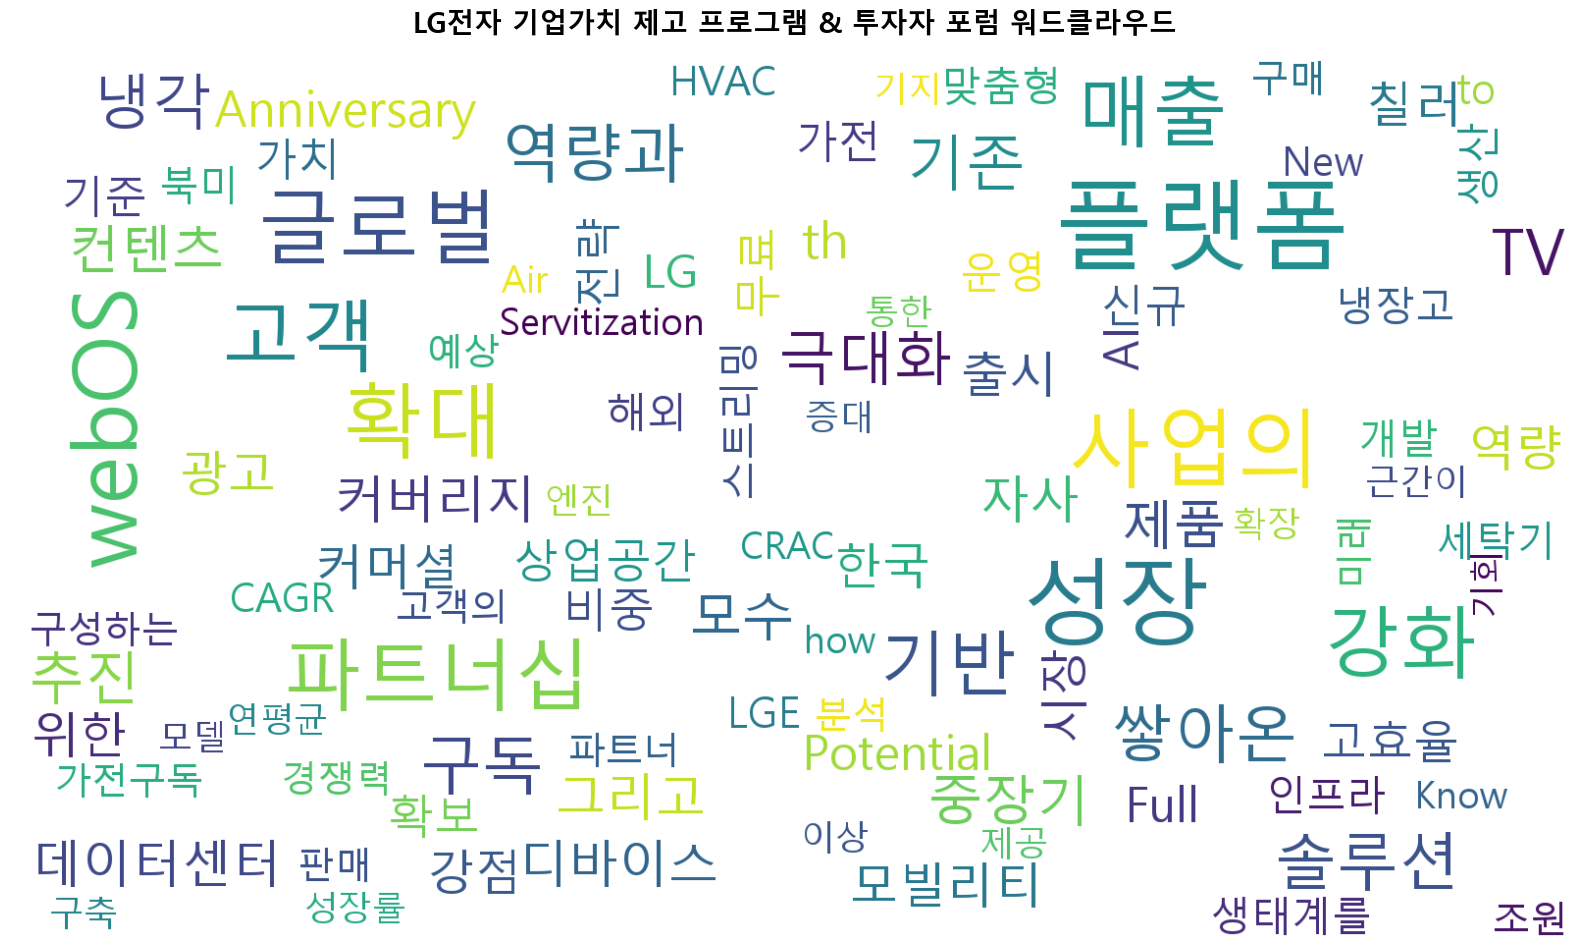

✅ 전체 워드클라우드 생성 완료!


In [28]:
# 전체 워드클라우드 생성
def create_wordcloud(token_df, top_n=100, figsize=(16, 10)):
    """
    토큰 DataFrame을 이용하여 워드클라우드 생성
    """
    print(f"☁️ 전체 워드클라우드 생성 중... (상위 {top_n}개 단어)")
    
    # 상위 N개 토큰 선택
    top_tokens = token_df.head(top_n)
    
    # 빈도수를 딕셔너리로 변환
    word_freq = dict(zip(top_tokens['token'], top_tokens['total_frequency']))
    
    print(f"  📊 워드클라우드 단어 수: {len(word_freq)}개")
    print(f"  🏆 최고 빈도 단어: {top_tokens.iloc[0]['token']} ({top_tokens.iloc[0]['total_frequency']}회)")
    
    # 워드클라우드 객체 생성
    wordcloud = WordCloud(
        width=1600,
        height=900,
        background_color='white',
        max_words=top_n,
        colormap='viridis',
        font_path='C:/Windows/Fonts/malgun.ttf',  # Windows 한글 폰트
        relative_scaling=0.5,
        min_font_size=8,
        max_font_size=100
    ).generate_from_frequencies(word_freq)
    
    # 전체 워드클라우드 그리기
    plt.figure(figsize=figsize)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('LG전자 기업가치 제고 프로그램 & 투자자 포럼 워드클라우드', 
              fontsize=20, pad=20, fontweight='bold')
    plt.tight_layout()
    
    # 이미지 저장
    plt.savefig('lg_corporate_value_wordcloud_overall.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ 전체 워드클라우드 생성 완료!")
    return wordcloud

# 전체 워드클라우드 생성
wordcloud_overall = create_wordcloud(token_df)

📊 문서별 워드클라우드 생성 중... (각 문서당 상위 50개 단어)
  📄 Corporate_Value_up_1 워드클라우드 생성 중...
    ✅ Corporate_Value_up_1: 25개 단어로 워드클라우드 생성
  📄 Corporate_Value_up_2 워드클라우드 생성 중...
    ❌ Corporate_Value_up_2: 데이터 없음
  📄 Investor_Forum 워드클라우드 생성 중...
    ✅ Investor_Forum: 50개 단어로 워드클라우드 생성


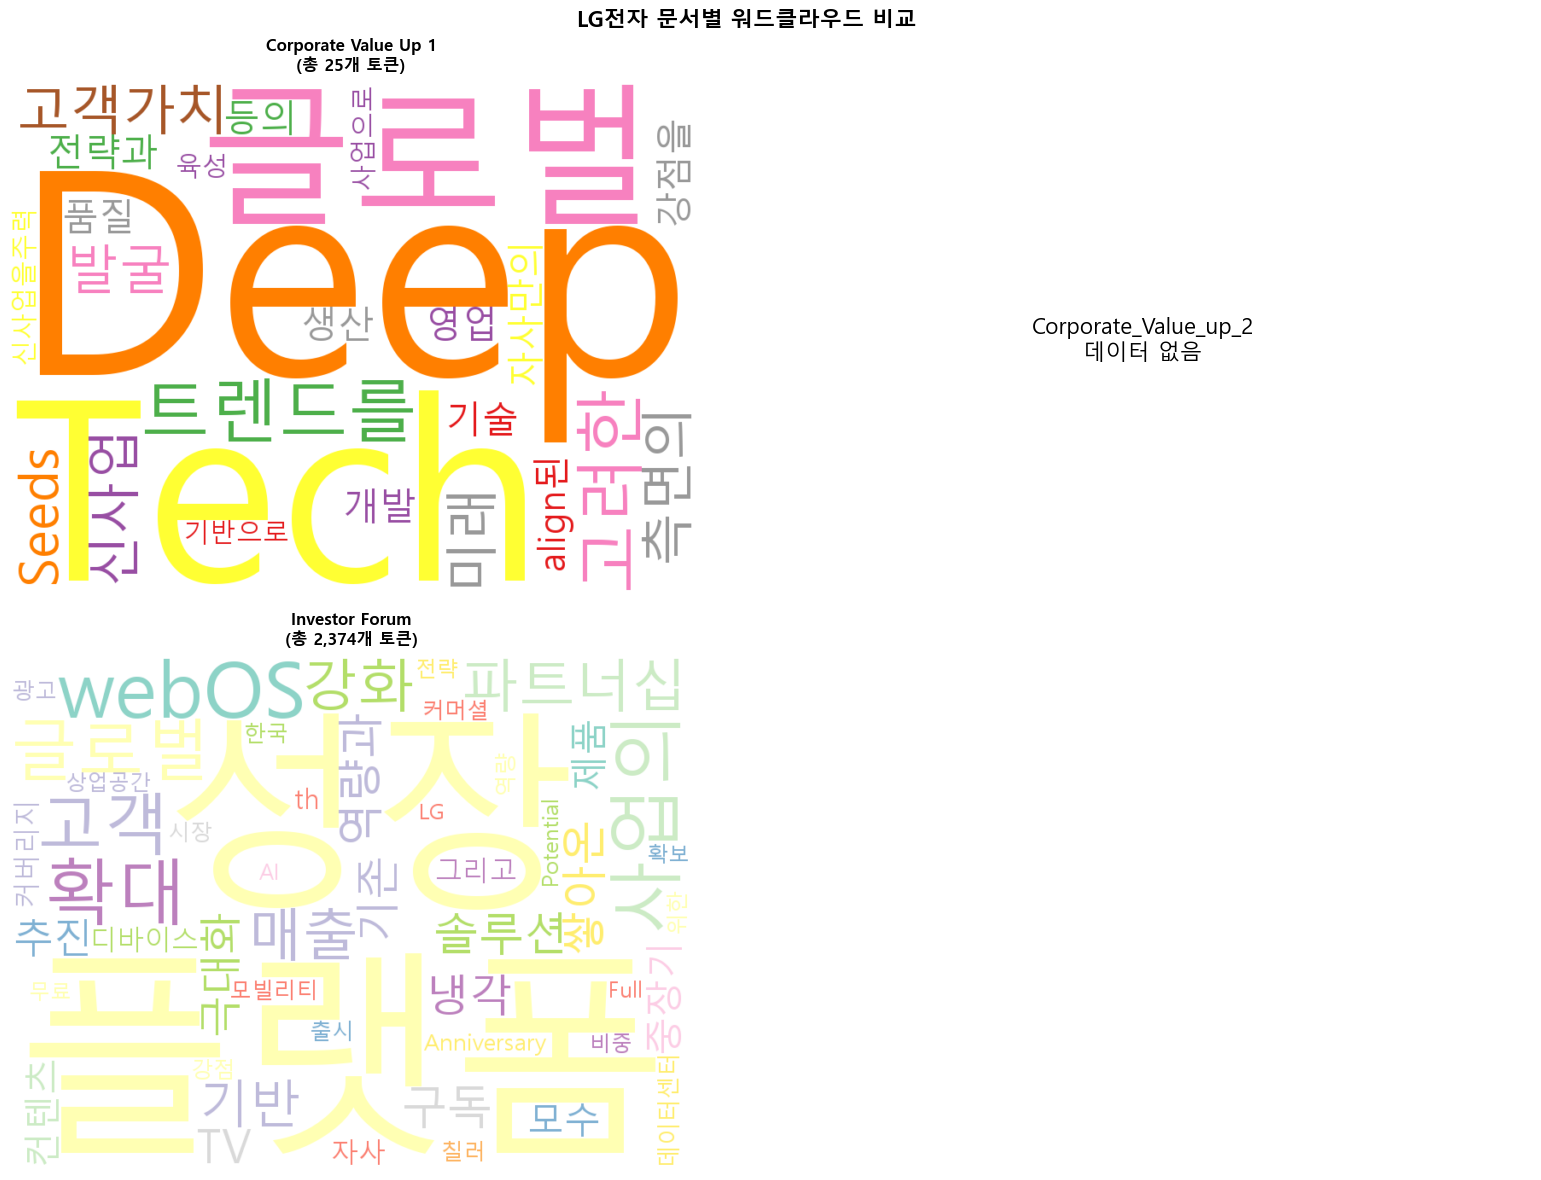

✅ 문서별 워드클라우드 생성 완료!


In [29]:
# 문서별 워드클라우드 생성
def create_document_wordclouds(tokens_dict, top_n=50):
    """
    문서별로 개별 워드클라우드 생성
    """
    print(f"📊 문서별 워드클라우드 생성 중... (각 문서당 상위 {top_n}개 단어)")
    
    docs = list(tokens_dict.keys())
    n_docs = len(docs)
    
    # 서브플롯 구성 결정
    if n_docs <= 2:
        fig, axes = plt.subplots(1, n_docs, figsize=(8*n_docs, 8))
        if n_docs == 1:
            axes = [axes]
    else:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        axes = axes.flatten()
    
    for i, doc_type in enumerate(docs):
        if i >= len(axes):  # 축 개수보다 문서가 많을 경우
            break
            
        print(f"  📄 {doc_type} 워드클라우드 생성 중...")
        
        # 해당 문서 토큰 빈도 계산
        doc_tokens = tokens_dict[doc_type]
        doc_freq = Counter(doc_tokens)
        
        # 상위 N개 선택
        top_doc_tokens = dict(doc_freq.most_common(top_n))
        
        if top_doc_tokens:  # 토큰이 있을 경우에만
            # 워드클라우드 생성
            wordcloud = WordCloud(
                width=800,
                height=600,
                background_color='white',
                max_words=top_n,
                colormap=['Set1', 'Set2', 'Set3'][i % 3],
                font_path='C:/Windows/Fonts/malgun.ttf',
                relative_scaling=0.5,
                min_font_size=8
            ).generate_from_frequencies(top_doc_tokens)
            
            # 서브플롯에 그리기
            axes[i].imshow(wordcloud, interpolation='bilinear')
            axes[i].axis('off')
            
            # 제목 설정
            doc_title = doc_type.replace('_', ' ').title()
            axes[i].set_title(f'{doc_title}\n(총 {len(doc_tokens):,}개 토큰)', 
                            fontsize=12, pad=10, fontweight='bold')
            
            print(f"    ✅ {doc_type}: {len(top_doc_tokens)}개 단어로 워드클라우드 생성")
        else:
            axes[i].text(0.5, 0.5, f'{doc_type}\n데이터 없음', 
                        ha='center', va='center', fontsize=16)
            axes[i].axis('off')
            print(f"    ❌ {doc_type}: 데이터 없음")
    
    # 빈 서브플롯 숨기기
    for j in range(len(docs), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle('LG전자 문서별 워드클라우드 비교', fontsize=16, y=0.98, fontweight='bold')
    plt.tight_layout()
    
    # 이미지 저장
    plt.savefig('lg_corporate_value_wordcloud_by_document.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ 문서별 워드클라우드 생성 완료!")

# 문서별 워드클라우드 생성
create_document_wordclouds(all_tokens)

📈 상위 20개 키워드 문서별 트렌드 분석
  📋 분석 문서: Corporate_Value_up_1, Corporate_Value_up_2, Investor_Forum


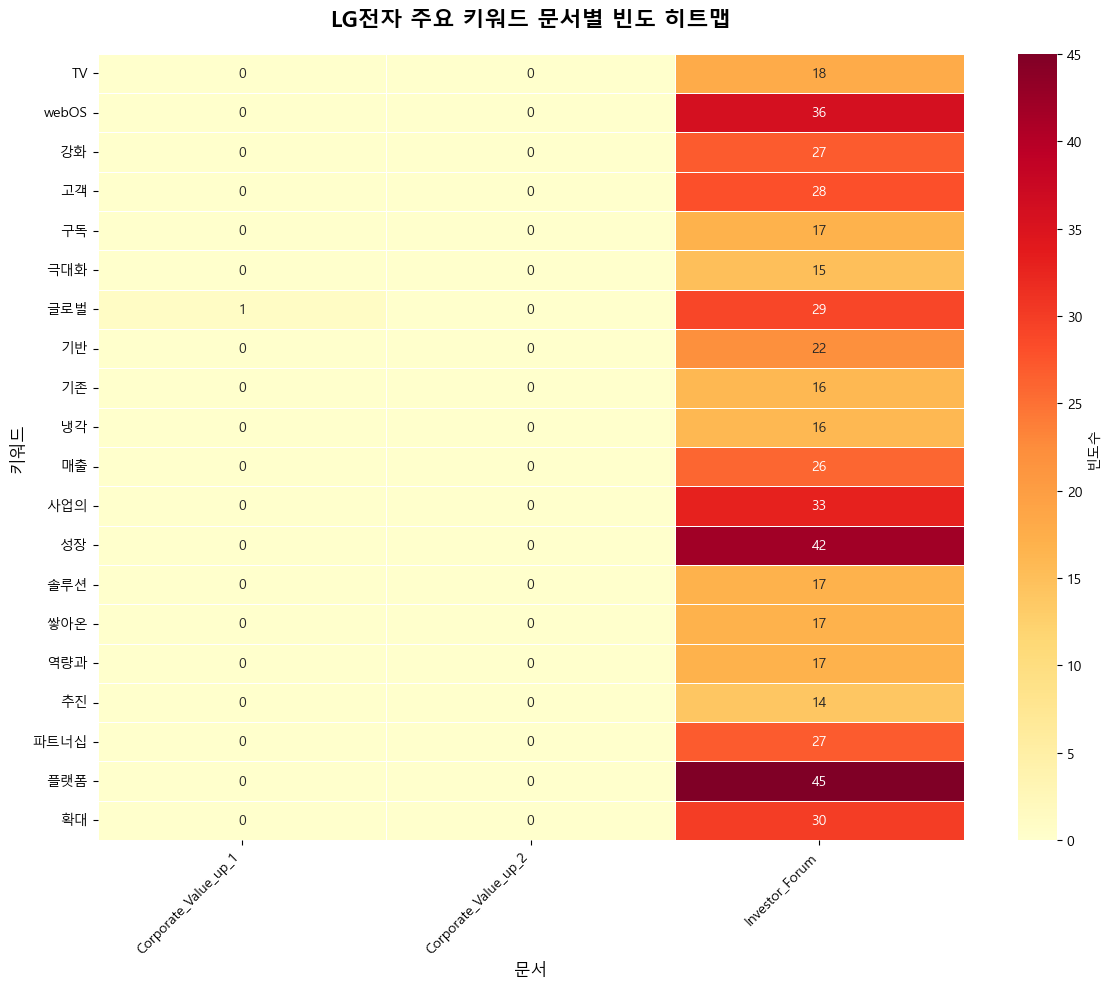

✅ 키워드 트렌드 분석 완료!


In [30]:
# 키워드 트렌드 분석 (문서별 비교)
def analyze_keyword_trends(token_df, top_keywords=20):
    """
    주요 키워드들의 문서별 빈도 비교 분석
    """
    print(f"📈 상위 {top_keywords}개 키워드 문서별 트렌드 분석")
    
    # 상위 키워드 선택
    top_tokens = token_df.head(top_keywords)['token'].tolist()
    
    # 문서별 빈도 데이터 추출
    doc_columns = [col for col in token_df.columns if '_frequency' in col and col != 'total_frequency']
    documents = [col.replace('_frequency', '') for col in doc_columns]
    
    print(f"  📋 분석 문서: {', '.join(documents)}")
    
    # 트렌드 시각화를 위한 데이터 준비
    trend_data = []
    
    for token in top_tokens:
        token_row = token_df[token_df['token'] == token].iloc[0]
        for doc in documents:
            frequency = token_row[f'{doc}_frequency']
            percentage = token_row[f'{doc}_percentage']
            
            trend_data.append({
                'token': token,
                'document': doc,
                'frequency': frequency,
                'percentage': percentage
            })
    
    trend_df = pd.DataFrame(trend_data)
    
    # 히트맵으로 키워드 트렌드 시각화
    plt.figure(figsize=(12, 10))
    
    # 피벗 테이블 생성 (빈도 기준)
    pivot_freq = trend_df.pivot(index='token', columns='document', values='frequency')
    
    # 히트맵 그리기
    sns.heatmap(pivot_freq, annot=True, fmt='d', cmap='YlOrRd', 
                cbar_kws={'label': '빈도수'}, linewidths=0.5)
    
    plt.title('LG전자 주요 키워드 문서별 빈도 히트맵', fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('문서', fontsize=12)
    plt.ylabel('키워드', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # 이미지 저장
    plt.savefig('lg_corporate_value_keyword_trends.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ 키워드 트렌드 분석 완료!")
    return trend_df

# 키워드 트렌드 분석
trend_analysis = analyze_keyword_trends(token_df)

In [31]:
# 분석 결과 종합 요약
def generate_analysis_summary(token_df, extracted_texts, trend_df):
    """
    분석 결과 종합 요약 생성
    """
    print("📋 분석 결과 요약 생성 중...")
    
    # 문서별 토큰 수 계산
    doc_token_counts = {}
    for doc in trend_df['document'].unique():
        doc_token_counts[doc] = trend_df[trend_df['document'] == doc]['frequency'].sum()
    
    summary = {
        '분석_일시': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        '분석_파일_수': len(extracted_texts),
        '전체_고유_토큰_수': len(token_df),
        '전체_토큰_수': token_df['total_frequency'].sum(),
        '상위_15개_키워드': token_df.head(15)['token'].tolist(),
        '문서별_텍스트_길이': {doc: len(text) for doc, text in extracted_texts.items()},
        '문서별_토큰_수': doc_token_counts
    }
    
    print("\n" + "="*70)
    print("🎯 LG전자 기업가치 제고 프로그램 & 투자자 포럼 워드클라우드 분석 결과")
    print("="*70)
    
    print(f"📅 분석 일시: {summary['분석_일시']}")
    print(f"📄 분석 파일 수: {summary['분석_파일_수']}개")
    print(f"🔤 전체 고유 토큰 수: {summary['전체_고유_토큰_수']:,}개")
    print(f"📊 전체 토큰 수: {summary['전체_토큰_수']:,}개")
    
    print("\n🏆 상위 15개 핵심 키워드:")
    for i, keyword in enumerate(summary['상위_15개_키워드'], 1):
        frequency = token_df[token_df['token'] == keyword]['total_frequency'].iloc[0]
        percentage = token_df[token_df['token'] == keyword]['total_percentage'].iloc[0]
        print(f"  {i:2d}. {keyword:15s} - {frequency:4d}회 ({percentage:.2f}%)")
    
    print("\n📈 문서별 분석 현황:")
    for doc in summary['문서별_텍스트_길이'].keys():
        text_length = summary['문서별_텍스트_길이'][doc]
        token_count = summary['문서별_토큰_수'].get(doc, 0)
        doc_name = doc.replace('_', ' ').title()
        print(f"  📋 {doc_name:25s}: 텍스트 {text_length:,}자, 토큰 {token_count:,}개")
    
    print("\n💾 생성된 파일:")
    print("  📊 lg_corporate_value_token_analysis.xml - 토큰 분석 데이터")
    print("  ☁️ lg_corporate_value_wordcloud_overall.png - 전체 워드클라우드")
    print("  📅 lg_corporate_value_wordcloud_by_document.png - 문서별 워드클라우드")
    print("  📈 lg_corporate_value_keyword_trends.png - 키워드 트렌드 분석")
    
    print("\n✅ 분석 완료!")
    print("="*70)
    
    return summary

# 최종 요약 생성
final_summary = generate_analysis_summary(token_df, extracted_texts, trend_analysis)

📋 분석 결과 요약 생성 중...

🎯 LG전자 기업가치 제고 프로그램 & 투자자 포럼 워드클라우드 분석 결과
📅 분석 일시: 2025-07-30 14:47:52
📄 분석 파일 수: 3개
🔤 전체 고유 토큰 수: 944개
📊 전체 토큰 수: 2,399개

🏆 상위 15개 핵심 키워드:
   1. 플랫폼             -   45회 (1.88%)
   2. 성장              -   42회 (1.75%)
   3. webOS           -   36회 (1.50%)
   4. 사업의             -   33회 (1.38%)
   5. 글로벌             -   30회 (1.25%)
   6. 확대              -   30회 (1.25%)
   7. 고객              -   28회 (1.17%)
   8. 파트너십            -   27회 (1.13%)
   9. 강화              -   27회 (1.13%)
  10. 매출              -   26회 (1.08%)
  11. 기반              -   22회 (0.92%)
  12. TV              -   18회 (0.75%)
  13. 솔루션             -   17회 (0.71%)
  14. 구독              -   17회 (0.71%)
  15. 쌓아온             -   17회 (0.71%)

📈 문서별 분석 현황:
  📋 Corporate Value Up 1     : 텍스트 137자, 토큰 1개
  📋 Corporate Value Up 2     : 텍스트 13자, 토큰 0개
  📋 Investor Forum           : 텍스트 15,687자, 토큰 492개

💾 생성된 파일:
  📊 lg_corporate_value_token_analysis.xml - 토큰 분석 데이터
  ☁️ lg_corporate_value_wordcloud_overall.png 

🔍 토큰 특성 및 통계 분석 중...


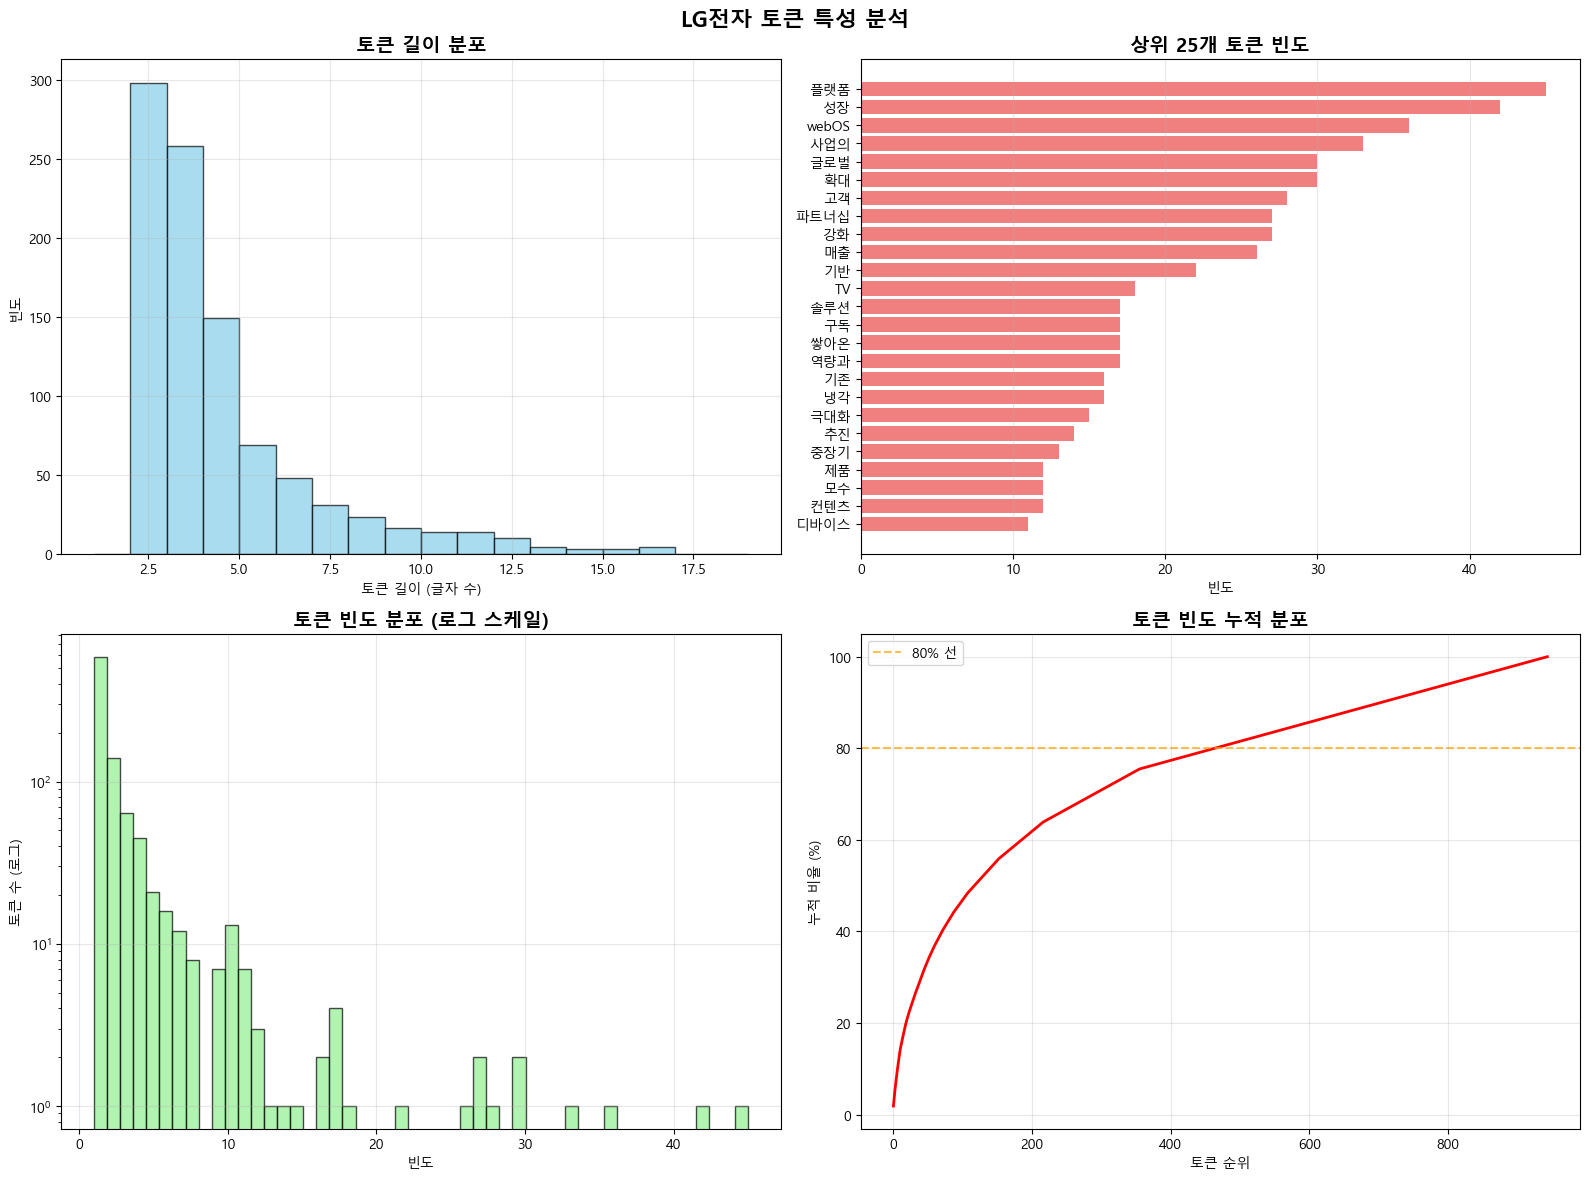


📊 문서별 고유 토큰 분석:
  📋 Corporate_Value_up_1     : 고유 25개 / 전체 25개 (100.0%)


ZeroDivisionError: division by zero

In [32]:
# 추가 분석: 토큰 특성 및 통계 분석
def analyze_token_characteristics(token_df, all_tokens):
    """
    토큰 특성 분석 (길이, 분포, 문서별 고유성 등)
    """
    print("🔍 토큰 특성 및 통계 분석 중...")
    
    # 토큰 길이 분석
    token_df['token_length'] = token_df['token'].str.len()
    
    # 시각화
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. 토큰 길이 분포
    axes[0, 0].hist(token_df['token_length'], bins=range(1, 20), alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('토큰 길이 분포', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('토큰 길이 (글자 수)')
    axes[0, 0].set_ylabel('빈도')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. 상위 25개 토큰 빈도 막대그래프
    top_25 = token_df.head(25)
    y_pos = np.arange(len(top_25))
    axes[0, 1].barh(y_pos, top_25['total_frequency'], color='lightcoral')
    axes[0, 1].set_yticks(y_pos)
    axes[0, 1].set_yticklabels(top_25['token'])
    axes[0, 1].set_title('상위 25개 토큰 빈도', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('빈도')
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # 3. 빈도 분포 (로그 스케일)
    axes[1, 0].hist(token_df['total_frequency'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_title('토큰 빈도 분포 (로그 스케일)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('빈도')
    axes[1, 0].set_ylabel('토큰 수 (로그)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. 누적 분포
    cumulative_pct = (token_df['total_frequency'].cumsum() / token_df['total_frequency'].sum() * 100)
    axes[1, 1].plot(range(len(cumulative_pct)), cumulative_pct, color='red', linewidth=2)
    axes[1, 1].set_title('토큰 빈도 누적 분포', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('토큰 순위')
    axes[1, 1].set_ylabel('누적 비율 (%)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='80% 선')
    axes[1, 1].legend()
    
    plt.suptitle('LG전자 토큰 특성 분석', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('lg_corporate_value_token_characteristics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 문서별 고유 토큰 분석
    print("\n📊 문서별 고유 토큰 분석:")
    for doc_name, tokens in all_tokens.items():
        unique_tokens = len(set(tokens))
        total_tokens = len(tokens)
        uniqueness_ratio = unique_tokens / total_tokens * 100
        print(f"  📋 {doc_name:25s}: 고유 {unique_tokens:,}개 / 전체 {total_tokens:,}개 ({uniqueness_ratio:.1f}%)")
    
    # 통계 요약
    print("\n📊 전체 토큰 통계 요약:")
    print(f"  평균 토큰 길이: {token_df['token_length'].mean():.2f}자")
    print(f"  중앙값 토큰 길이: {token_df['token_length'].median():.0f}자")
    print(f"  최대 토큰 길이: {token_df['token_length'].max()}자")
    print(f"  최소 토큰 길이: {token_df['token_length'].min()}자")
    
    # 파레토 분석
    pct_10 = int(len(cumulative_pct) * 0.1)
    pct_20 = int(len(cumulative_pct) * 0.2)
    pct_50 = int(len(cumulative_pct) * 0.5)
    
    print(f"  상위 10% 토큰이 전체 빈도의 {cumulative_pct.iloc[pct_10]:.1f}% 차지")
    print(f"  상위 20% 토큰이 전체 빈도의 {cumulative_pct.iloc[pct_20]:.1f}% 차지")
    print(f"  상위 50% 토큰이 전체 빈도의 {cumulative_pct.iloc[pct_50]:.1f}% 차지")

# 토큰 특성 분석 실행
analyze_token_characteristics(token_df, all_tokens)

print("\n🎉 모든 분석이 완료되었습니다!")
print("📁 생성된 모든 파일을 확인해보세요.")
print("\n📋 생성된 파일 목록:")
print("  • lg_corporate_value_token_analysis.xml")
print("  • lg_corporate_value_wordcloud_overall.png")
print("  • lg_corporate_value_wordcloud_by_document.png")
print("  • lg_corporate_value_keyword_trends.png")
print("  • lg_corporate_value_token_characteristics.png")